In [ ]:
from itertools import permutations

import numpy as np
from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator
from rdkit.Chem.EnumerateStereoisomers import (
    EnumerateStereoisomers,
    StereoEnumerationOptions,
)
from stereomolgraph import StereoMolGraph
from stereomolgraph.algorithms.circular import circular_stereo_generator

In [8]:
# Canonical valinomycin SMILES (all stereo defined)
valinomycin_smiles = (
    "C[C@H]1C(=O)N[C@H](C(=O)O[C@@H](C(=O)N[C@@H](C(=O)O[C@H]"
    "(C(=O)N[C@H](C(=O)O[C@@H](C(=O)N[C@@H](C(=O)O[C@H]"
    "(C(=O)N[C@H](C(=O)O[C@@H](C(=O)N[C@@H](C(=O)O1)"
    "C(C)C)C(C)C)C(C)C)C)C(C)C)C(C)C)C(C)C)C)C(C)C)C(C)C)C(C)C"
)

mol = Chem.MolFromSmiles(valinomycin_smiles)
centers = Chem.FindMolChiralCenters(mol, includeUnassigned=True)
print(f"Stereocenters: {len(centers)}")

# Enumerate ALL stereoisomers (flip every center)
opts = StereoEnumerationOptions(unique=True, onlyUnassigned=False)
stereoisomers = list(EnumerateStereoisomers(mol, options=opts))
print(f"Stereoisomers: {len(stereoisomers)}")

Stereocenters: 12
Stereoisomers: 1024


Saved ../figures/valinomycin_2d.svg and ../figures/valinomycin_2d.png


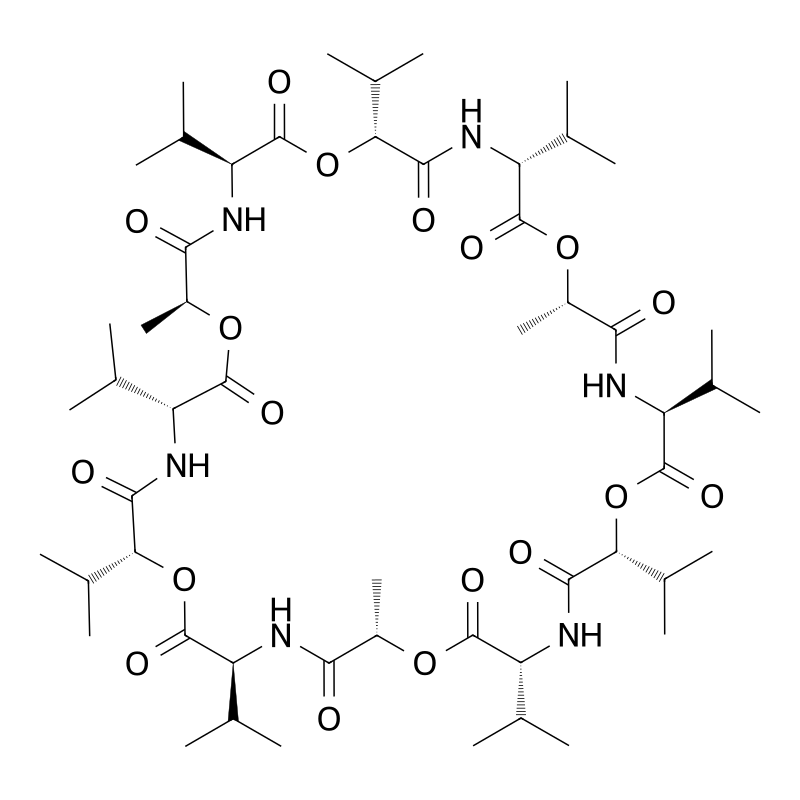

In [9]:
from IPython.display import SVG, display
from rdkit.Chem import Draw, rdCoordGen

# Use the valinomycin mol from above
mol = Chem.MolFromSmiles(valinomycin_smiles)

# CoordGen gives much nicer layouts for macrocycles than the default RDKit method
rdCoordGen.AddCoords(mol)

# High-quality SVG drawing
drawer = Draw.MolDraw2DSVG(800, 800)
dopts = drawer.drawOptions()
dopts.bondLineWidth = 1.5
dopts.additionalAtomLabelPadding = 0.15
dopts.multipleBondOffset = 0.18
dopts.setBackgroundColour((1, 1, 1, 1))
dopts.useBWAtomPalette()

drawer.DrawMolecule(mol)
drawer.FinishDrawing()
svg_text = drawer.GetDrawingText()

# Save SVG
svg_path = "../figures/valinomycin_2d.svg"
with open(svg_path, "w") as f:
    f.write(svg_text)

# Save high-res PNG via RDKit's bitmap drawer
png_drawer = Draw.MolDraw2DCairo(2400, 2400)
popts = png_drawer.drawOptions()
popts.bondLineWidth = 1.5 * 3  # scale up for higher resolution
popts.additionalAtomLabelPadding = 0.15
popts.multipleBondOffset = 0.18
popts.setBackgroundColour((1, 1, 1, 1))
popts.useBWAtomPalette()

png_drawer.DrawMolecule(mol)
png_drawer.FinishDrawing()

png_path = "../figures/valinomycin_2d.png"
with open(png_path, "wb") as f:
    f.write(png_drawer.GetDrawingText())

print(f"Saved {svg_path} and {png_path}")
display(SVG(svg_text))

In [10]:
# ---------------------------------------------------------------------------
# Build the *sequence isomers* of valinomycin.
# Valinomycin = cyclo-(D-Val -- L-Lac -- L-Val -- D-HyIv) x 3
# The 4 building blocks per repeat (using SMILES fragments with [*]):
#   A = D-Val   amide-linked amino acid   N-end … C(=O) ester-end
#   B = L-Lac   ester-linked hydroxy acid  O-end … C(=O) amide-end
#   C = L-Val   amide-linked amino acid
#   D = D-HyIv  ester-linked hydroxy acid
#
# A sequence isomer = any cyclic permutation-inequivalent ordering of
# {A, B, C, D} within one repeat unit, repeated 3 times, then cyclised.
# Because the ring has 3 identical repeats, many permutations of the 4
# building blocks collapse.  We generate all 4! = 24 orderings, build
# the 3-fold repeat, canonicalise, and deduplicate.
# ---------------------------------------------------------------------------

# Building blocks as (SMILES_body, link_left, link_right)
# Amino acids contribute:  N–CHR–C(=O)   (amide bond on left, ester on right)
# Hydroxy acids contribute: O–CHR–C(=O)  (ester bond on left, amide on right)
# We'll construct the linear trimer and cyclise with RDKit.

# Monomer SMILES fragments (open-chain, with [*] attachment points)
# left=[*] is where the previous C(=O) attaches; right=C([*])=O provides the next C(=O)
monomers = {
    "D-Val": "[C@H](C(C)C)",  # amino acid  -> gives N-CHR-C(=O)
    "L-Lac": "[C@@H](C)",  # hydroxy acid -> gives O-CHR-C(=O)
    "L-Val": "[C@@H](C(C)C)",  # amino acid
    "D-HyIv": "[C@H](C(C)C)",  # hydroxy acid
}
# linkage pattern: amino acid = amide bond (N), hydroxy acid = ester bond (O)
linkage = {
    "D-Val": "N",
    "L-Lac": "O",
    "L-Val": "N",
    "D-HyIv": "O",
}

canonical_order = ["D-Val", "L-Lac", "L-Val", "D-HyIv"]


def build_cyclic_depsipeptide(order, n_repeats=3):
    """Build a cyclic depsipeptide SMILES from an ordered list of monomer keys."""
    # Construct the linear chain: linkage-CHR-C(=O)-linkage-CHR-C(=O)-...
    # Then cyclise by connecting last C(=O) to first linkage atom.
    parts = []
    for key in order * n_repeats:
        parts.append(f"{linkage[key]}{monomers[key]}C(=O)")
    linear = "".join(parts)
    # Cyclise: wrap first atom in ring-open '1' and last C(=O) closes to it
    # The linear SMILES looks like: N[C@H](...)C(=O)O[C@@H](...)C(=O)...
    # We need         ...C(=O)1  (ring closure back to the leading N or O)
    # i.e. first_linkage_atom ... C(=O) -> ring close
    cyclic = linear[0] + "1" + linear[1:] + "1"
    mol = Chem.MolFromSmiles(cyclic)
    if mol is None:
        return None
    return Chem.MolToSmiles(mol)  # canonicalise


# Generate all distinct sequence isomers (cyclic permutation equivalences
# are handled by SMILES canonicalisation)
seen = set()
sequence_smiles = []
for perm in permutations(canonical_order):
    smi = build_cyclic_depsipeptide(list(perm))
    if smi is not None and smi not in seen:
        seen.add(smi)
        sequence_smiles.append(smi)

print(f"Distinct sequence isomers: {len(sequence_smiles)}")

# Now enumerate stereoisomers for every sequence isomer
all_mols = []
all_labels = []  # (seq_idx, stereo_idx)
opts = StereoEnumerationOptions(unique=True, onlyUnassigned=False)

for seq_idx, smi in enumerate(sequence_smiles):
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        continue
    stereo_list = list(EnumerateStereoisomers(mol, options=opts))
    for st_idx, st_mol in enumerate(stereo_list):
        all_mols.append(st_mol)
        all_labels.append((seq_idx, st_idx))

print(f"Total molecules (sequence x stereo): {len(all_mols)}")

Distinct sequence isomers: 6
Total molecules (sequence x stereo): 6144


In [ ]:
# ---------------------------------------------------------------------------
# Count *distinct* atom fingerprints per molecule for SMG and ECFP
# We compare SMG(r) vs ECFP(r-1) following the tanimoto.ipynb convention.
# ---------------------------------------------------------------------------
from tqdm import tqdm

radii_smg = [3, 4]  # SMG radii to evaluate
radii_ecfp = [2, 3]  # matched ECFP radii (r-1)


def n_distinct_ecfp(mol, radius, include_chirality=True):
    """Number of distinct Morgan features (non-folded sparse count)."""
    fp_gen = rdFingerprintGenerator.GetMorganGenerator(
        radius=radius,
        includeChirality=include_chirality,
        fpSize=2048,
    )
    sparse = fp_gen.GetSparseCountFingerprint(mol)
    return len(sparse.GetNonzeroElements())


def n_distinct_smg(mol, radius, include_hydrogens=False):
    """Number of distinct SMG colours at a given radius."""
    smg = StereoMolGraph.from_rdmol(mol, stereo_complete=True)
    gen = circular_stereo_generator(smg)
    for r, colors in enumerate(gen):
        if r == radius:
            if not include_hydrogens:
                non_h = [i for i, at in enumerate(smg.atom_types) if at != 1]
                colors = colors[non_h]
            return len(set(colors.tolist()))
    return 0


# Collect counts
n_ecfp = {r: [] for r in radii_ecfp}
n_smg = {r: [] for r in radii_smg}

for mol in tqdm(all_mols, desc="distinct features"):
    for r in radii_ecfp:
        n_ecfp[r].append(n_distinct_ecfp(mol, r))
    for r in radii_smg:
        n_smg[r].append(n_distinct_smg(mol, r))

# Print summary
for re, rs in zip(radii_ecfp, radii_smg):
    print(
        f"ECFP(r={re}): mean={np.mean(n_ecfp[re]):.1f}, "
        f"SMG(r={rs}): mean={np.mean(n_smg[rs]):.1f}"
    )

distinct features: 100%|██████████| 6144/6144 [01:01<00:00, 100.23it/s]

ECFP(r=2): mean=42.7, SMG(r=3): mean=31.3
ECFP(r=3): mean=67.7, SMG(r=4): mean=42.8


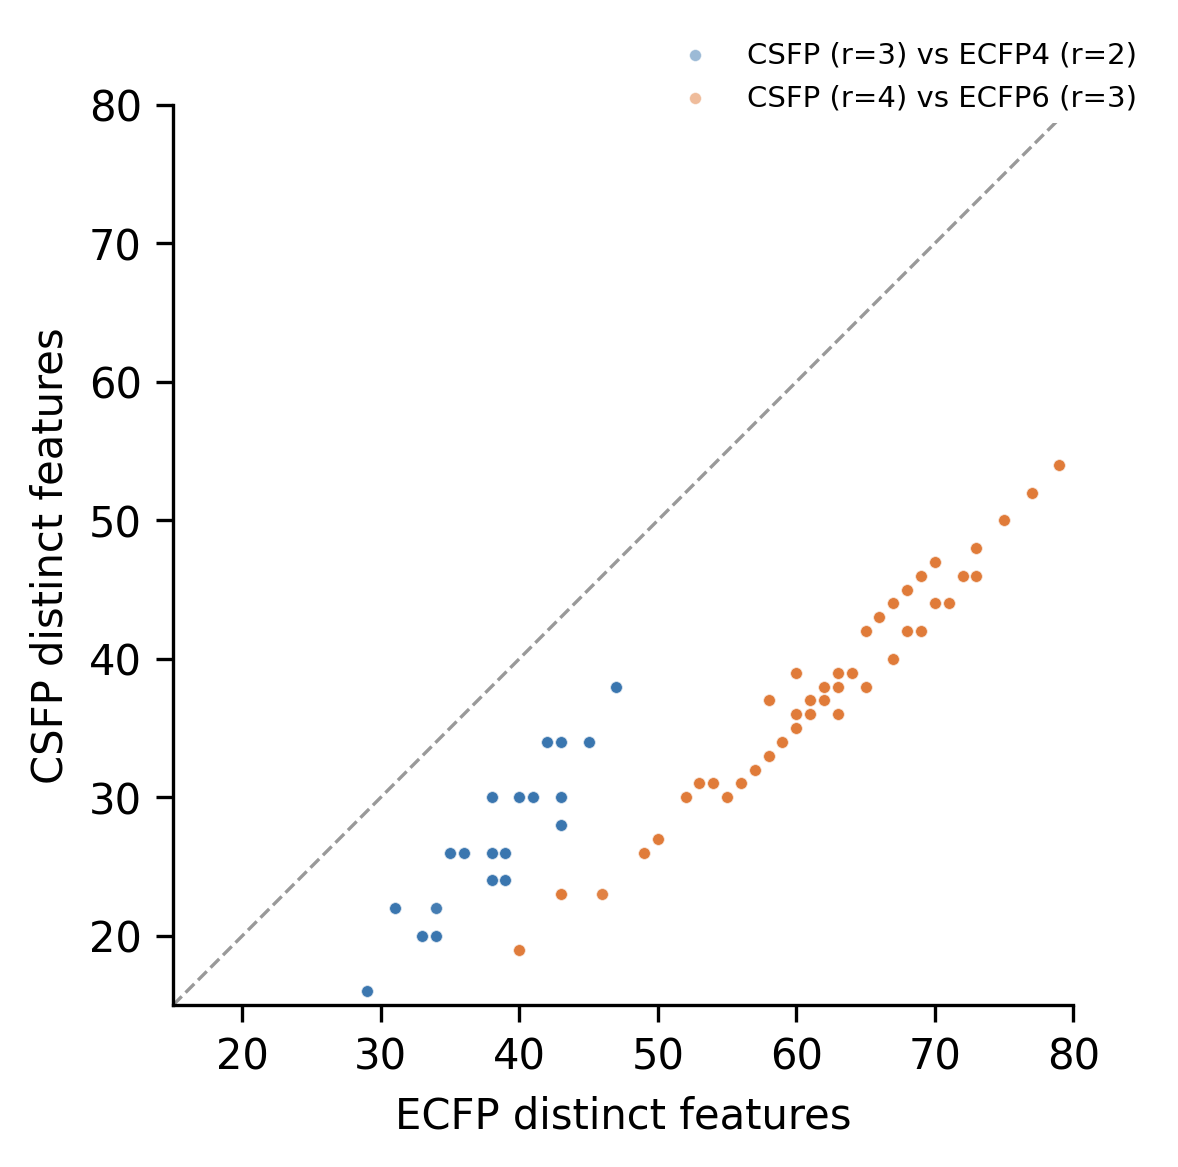

In [12]:
import matplotlib as mpl
import matplotlib.pyplot as plt

# Publication styling (matches tm_compare2.ipynb)
mpl.rcParams.update(
    {
        "font.family": "sans-serif",
        "font.size": 10,
        "axes.linewidth": 0.8,
        "xtick.major.width": 0.8,
        "ytick.major.width": 0.8,
        "xtick.major.size": 4,
        "ytick.major.size": 4,
        "figure.dpi": 300,
    }
)

fig, ax = plt.subplots(figsize=(4.5, 4.0))

# r=2 / r=3 pair
ecfp2 = np.asarray(n_ecfp[2], dtype=float)
smg3 = np.asarray(n_smg[3], dtype=float)
ax.scatter(
    ecfp2,
    smg3,
    s=8,
    alpha=0.5,
    color="#3A76AF",
    edgecolors="white",
    linewidths=0.2,
    label="CSFP (r=3) vs ECFP4 (r=2)",
)

# r=3 / r=4 pair
ecfp3 = np.asarray(n_ecfp[3], dtype=float)
smg4 = np.asarray(n_smg[4], dtype=float)
ax.scatter(
    ecfp3,
    smg4,
    s=8,
    alpha=0.5,
    color="#E07B39",
    edgecolors="white",
    linewidths=0.2,
    label="CSFP (r=4) vs ECFP6 (r=3)",
)

# Identity line spanning the full data range
all_vals = np.concatenate([ecfp2, smg3, ecfp3, smg4])
lo = all_vals.min() - 1
hi = all_vals.max() + 1
ax.plot(
    [lo, hi], [lo, hi], ls="--", lw=0.8, color="0.6", zorder=0, clip_on=True
)

ax.set_xlabel("ECFP distinct features", fontsize=10)
ax.set_ylabel("CSFP distinct features", fontsize=10)
ax.set_xlim(lo, hi)
ax.set_ylim(lo, hi)
ax.set_aspect("equal")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
# ax.yaxis.grid(True, lw=0.4, alpha=0.4, color="0.7")
# ax.xaxis.grid(True, lw=0.4, alpha=0.4, color="0.7")
ax.set_axisbelow(True)
leg = ax.legend(
    fontsize=7,
    frameon=True,
    loc="upper right",
    bbox_to_anchor=(1.1, 1.1),
    facecolor="white",
    edgecolor="none",
    framealpha=1,
)
leg.set_zorder(10)

fig.tight_layout()
fig.savefig("../figures/distinct_fp_valinomycin.pdf", bbox_inches="tight")
fig.savefig(
    "../figures/distinct_fp_valinomycin.png", bbox_inches="tight", dpi=300
)
fig.savefig("../figures/distinct_fp_valinomycin.svg", bbox_inches="tight")
plt.show()